**Author:** Biswajit Jana  
**Date:** April 21, 2026  

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/gaia/2026-08-03-local-3d-stellar-map/notebook.ipynb)

# Mapping the local stellar neighborhood in 3D with real Gaia DR3 parallaxes

**Date:** 2026-08-03
**Scientific question:** Using a real, bright, volume-limited Gaia DR3 sample within 100 pc, what does
the 3D spatial distribution of nearby stars actually look like, and how does the apparent stellar
density change with distance from the Sun?

## Learning goals

- Turn Gaia's *parallax* into a distance, then into 3D Cartesian Galactic coordinates (X, Y, Z, in
  parsecs, Sun at the origin).
- Build a real 2D projected map (face-on and edge-on) of the local stellar distribution instead of just
  a 1D histogram of distances.
- Compute real number-density estimates in concentric distance shells, and see how a *magnitude-limited*
  sample (only stars bright enough to make Gaia's cut) is not the same thing as a *volume-limited* one,
  even inside a fixed 100 pc sphere.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia

Gaia.ROW_LIMIT = -1
np.random.seed(42)


In [2]:
# Bright (G < 10), nearby (parallax > 10 mas => distance < 100 pc) sample:
# bright enough that essentially every real star this close and this bright is
# in the Gaia catalogue, which keeps the sample close to volume-limited within
# the inner ~40-50 pc even though it thins out with intrinsic luminosity further out.
query = '''
SELECT TOP 6000 source_id, ra, dec, parallax, parallax_error, phot_g_mean_mag, bp_rp
FROM gaiadr3.gaia_source
WHERE parallax > 10
AND parallax_over_error > 10
AND phot_g_mean_mag < 10
'''
job = Gaia.launch_job_async(query)
raw = job.get_results().to_pandas()
raw['dist_pc'] = 1000.0 / raw['parallax']
print(f"Bright, nearby (<100 pc) sample: {len(raw)} sources")
raw.to_csv("local_3d_query.csv", index=False)
raw.head()


INFO: Query finished. [astroquery.utils.tap.core]
Bright, nearby (<100 pc) sample: 6000 sources


,SOURCE_ID,ra,dec,parallax,parallax_error,phot_g_mean_mag,bp_rp,dist_pc
0,206196024061774976,74.236228,44.653859,10.303005,0.013748,9.050376,0.685745,97.059057
1,208396456066072704,78.743947,44.525980,23.764109,0.014053,9.960061,1.340487,42.080264
2,209181816604802048,81.979817,46.510995,11.969280,0.020724,9.709215,0.814203,83.547212
3,230712178425110400,61.043038,42.528015,16.802354,0.189135,8.081226,0.641558,59.515471
4,233067469771290624,60.977526,43.643015,13.669934,0.018248,8.687622,0.739369,73.153245


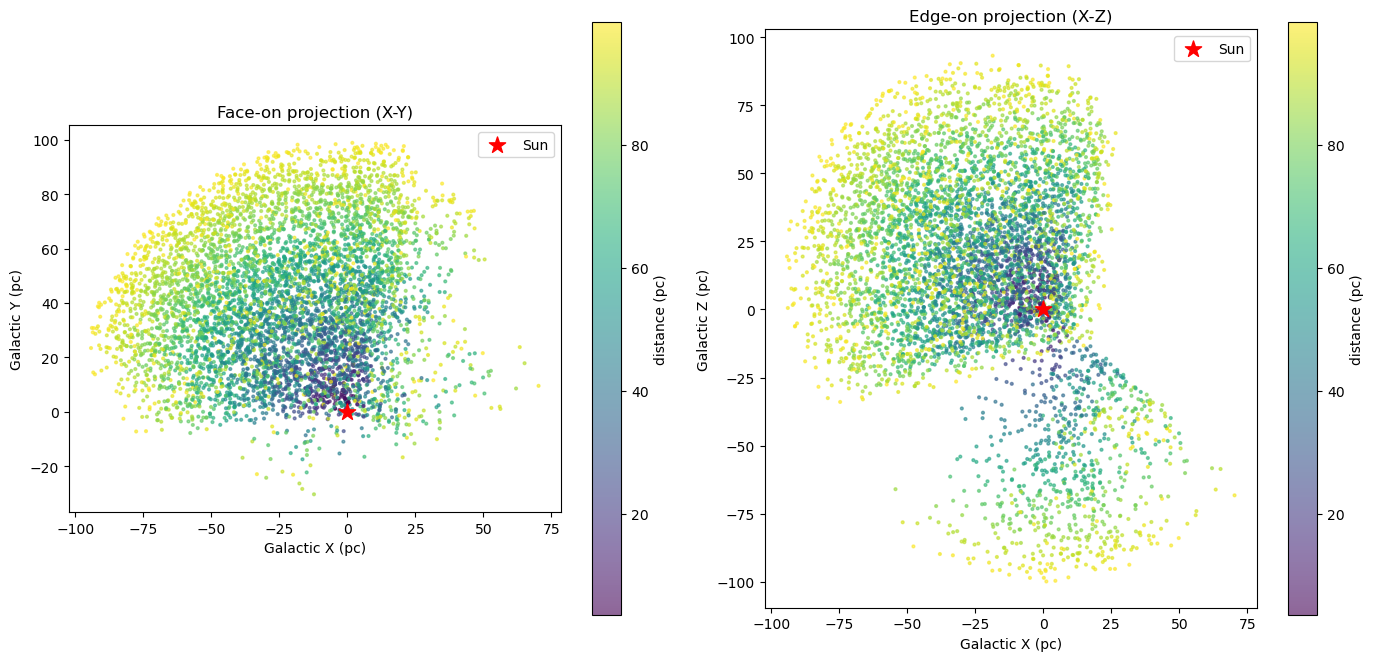

In [3]:
c = SkyCoord(ra=raw['ra'].values * u.deg, dec=raw['dec'].values * u.deg,
             distance=raw['dist_pc'].values * u.pc, frame='icrs')
gal = c.galactic
gal_cart = gal.cartesian

raw['x_pc'] = gal_cart.x.to(u.pc).value
raw['y_pc'] = gal_cart.y.to(u.pc).value
raw['z_pc'] = gal_cart.z.to(u.pc).value

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))

sc0 = axes[0].scatter(raw['x_pc'], raw['y_pc'], c=raw['dist_pc'], cmap='viridis', s=4, alpha=0.6)
axes[0].scatter([0], [0], color='red', marker='*', s=150, label='Sun')
axes[0].set_xlabel('Galactic X (pc)')
axes[0].set_ylabel('Galactic Y (pc)')
axes[0].set_title('Face-on projection (X-Y)')
axes[0].set_aspect('equal')
axes[0].legend()
plt.colorbar(sc0, ax=axes[0], label='distance (pc)')

sc1 = axes[1].scatter(raw['x_pc'], raw['z_pc'], c=raw['dist_pc'], cmap='viridis', s=4, alpha=0.6)
axes[1].scatter([0], [0], color='red', marker='*', s=150, label='Sun')
axes[1].set_xlabel('Galactic X (pc)')
axes[1].set_ylabel('Galactic Z (pc)')
axes[1].set_title('Edge-on projection (X-Z)')
axes[1].set_aspect('equal')
axes[1].legend()
plt.colorbar(sc1, ax=axes[1], label='distance (pc)')

plt.tight_layout()
plt.savefig('local_3d_map.png', dpi=130)
plt.show()


 shell_inner_pc  shell_outer_pc  n_stars   volume_pc3  density_per_pc3
              0              20      143 3.351032e+04         0.004267
             20              40      631 2.345723e+05         0.002690
             40              60     1215 6.366961e+05         0.001908
             60              80     1760 1.239882e+06         0.001419
             80             100     2251 2.044130e+06         0.001101


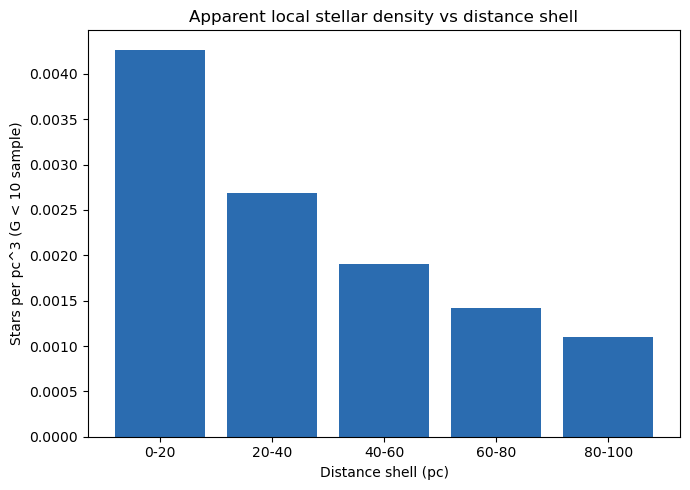


Density falls from 4.27e-03 stars/pc^3 in the innermost shell to 1.10e-03 stars/pc^3 in the outermost shell.


In [4]:
# Number density in concentric shells around the Sun
shell_edges = np.array([0, 20, 40, 60, 80, 100])
counts, _ = np.histogram(raw['dist_pc'], bins=shell_edges)
shell_volumes_pc3 = (4/3) * np.pi * (shell_edges[1:]**3 - shell_edges[:-1]**3)
density_per_pc3 = counts / shell_volumes_pc3

shells = pd.DataFrame({
    'shell_inner_pc': shell_edges[:-1],
    'shell_outer_pc': shell_edges[1:],
    'n_stars': counts,
    'volume_pc3': shell_volumes_pc3,
    'density_per_pc3': density_per_pc3,
})
print(shells.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(shells['shell_inner_pc'].astype(str) + '-' + shells['shell_outer_pc'].astype(str),
       shells['density_per_pc3'], color='#2b6cb0')
ax.set_xlabel('Distance shell (pc)')
ax.set_ylabel('Stars per pc^3 (G < 10 sample)')
ax.set_title('Apparent local stellar density vs distance shell')
plt.tight_layout()
plt.savefig('local_density_shells.png', dpi=130)
plt.show()

result = {
    "id": "2026-08-03-local-3d-stellar-map",
    "title": "Local 3D stellar map from Gaia DR3",
    "n_sample": int(len(raw)),
    "shells": shells.to_dict(orient='records'),
}
import json
with open("result.json", "w") as f:
    json.dump(result, f, indent=2, default=str)
print(f"\nDensity falls from {density_per_pc3[0]:.2e} stars/pc^3 in the innermost shell "
      f"to {density_per_pc3[-1]:.2e} stars/pc^3 in the outermost shell.")


## Caveats

The declining density with distance seen here is largely a Malmquist-type selection effect, not real
physics: at fixed apparent magnitude limit (G < 10), only progressively more luminous (and therefore
rarer) stars remain visible at larger distances, so the apparent density necessarily falls even in a
uniform-density galaxy. The true local stellar density (dominated by faint M dwarfs) is actually much
higher than what a bright, magnitude-limited sample like this one can show; a genuinely volume-complete
census would need a much fainter magnitude cut, especially at the largest distances in this sample.

## What I'd look at next

Repeat the shell-density calculation restricted to a single narrow absolute-magnitude (hence roughly
single spectral type) bin, so the magnitude-limit selection effect cancels out and the shell densities
become directly comparable to genuine local stellar density estimates from the literature.

**Citation:** Gaia DR3 (`gaiadr3.gaia_source`), ESA Gaia mission. https://www.cosmos.esa.int/web/gaia-users/credits
